# Part 2: Baseline Model (Linear Regression)
## 2.1 Preprocessing Pipeline

This notebook reads the checkpoint, builds the pipeline to handle imputations and encoding, and tracks the baseline model using MLflow.

In [5]:
# Apply Sklearn Optimizations for Intel CPUs
from sklearnex import patch_sklearn
patch_sklearn()

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score

# Load Processed Data (Checkpoint from Notebook 1)
file_path = '../data/processed/walmart_cleaned.csv'
df = pd.read_csv(file_path)

target_name = 'Weekly_Sales'
Y = df[target_name]
X = df.drop(target_name, axis=1)

# Define feature lists
categorical_features = ['Store', 'Holiday_Flag']
numerical_features = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Day', 'DayOfWeek']

# Train/Test Split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Build Preprocessing Pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


## 2.2 Model Training, Evaluation & MLflow Tracking

In [6]:
# Build the Baseline Model Pipeline
baseline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# MLflow Tracking Setup
# Set tracking URI to the root directory
mlflow.set_tracking_uri("file:../mlruns")
mlflow.set_experiment("Walmart_Sales_Prediction")

print("Starting MLflow run for Baseline Model...")
with mlflow.start_run(run_name="Baseline_Linear_Regression"):
    
    # Train the model
    baseline_model.fit(X_train, Y_train)
    
    # Predictions
    Y_train_pred = baseline_model.predict(X_train)
    Y_test_pred = baseline_model.predict(X_test)
    
    # Calculate Metrics
    r2_train = r2_score(Y_train, Y_train_pred)
    r2_test = r2_score(Y_test, Y_test_pred)
    
    # Log parameters and metrics
    mlflow.log_param("model_type", "LinearRegression")
    mlflow.log_metric("r2_train", r2_train)
    mlflow.log_metric("r2_test", r2_test)
    
    # Log the model
    mlflow.sklearn.log_model(baseline_model, "baseline_pipeline")
    
    print(f"Baseline Run completed. R2 Train: {r2_train:.4f} | R2 Test: {r2_test:.4f}")

c:\Users\ENava\anaconda3\envs\dsfs-base\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:178: FutureWarning: The filesystem tracking backend (e.g., './mlruns') will be deprecated in February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://github.com/mlflow/mlflow/issues/18534 for more details and migration guidance. For migrating existing data, https://github.com/mlflow/mlflow-export-import can be used.
  return FileStore(store_uri, store_uri)
2026/02/28 16:53:12 INFO mlflow.tracking.fluent: Experiment with name 'Walmart_Sales_Prediction' does not exist. Creating a new experiment.
2026/02/28 16:53:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Starting MLflow run for Baseline Model...


c:\Users\ENava\anaconda3\envs\dsfs-base\Lib\site-packages\mlflow\models\model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format.
  flavor.save_model(path=local_path, mlflow_model=mlflow_model, **kwargs)


Baseline Run completed. R2 Train: 0.9777 | R2 Test: 0.8900


## 2.3 Coefficient Analysis

--- Baseline Model Coefficients ---


,Feature,Coefficient
11,Store_5.0,-1.370505e+06
9,Store_3.0,-1.213923e+06
21,Store_16.0,-1.190217e+06
15,Store_9.0,-1.110698e+06
13,Store_7.0,-9.856512e+05
20,Store_15.0,-8.802522e+05
22,Store_17.0,-8.727120e+05
14,Store_8.0,-8.078687e+05
19,Store_14.0,5.788899e+05
10,Store_4.0,4.877074e+05


C:\Users\ENava\AppData\Local\Temp\ipykernel_4008\709691966.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='vlag')


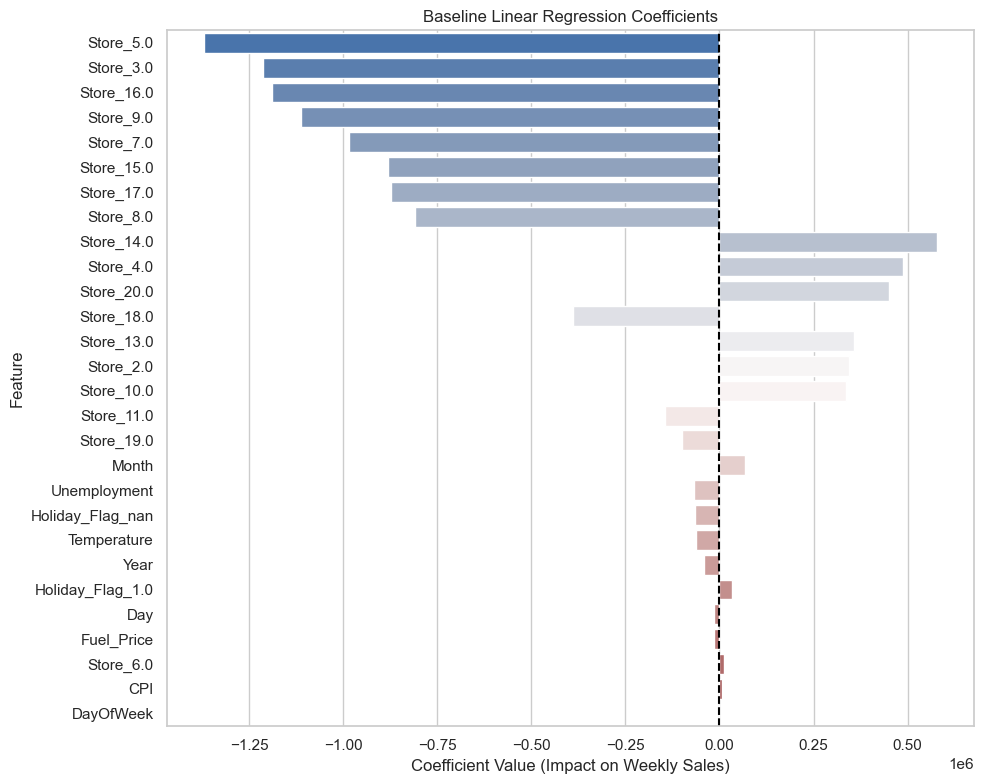

In [7]:
# ### 2.3 Coefficient Analysis

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract feature names from the preprocessor pipeline
# Numeric features are passed through directly
numeric_features_out = numerical_features

# Categorical features are transformed by OneHotEncoder
categorical_encoder = preprocessor.named_transformers_['cat'].named_steps['encoder']
categorical_features_out = categorical_encoder.get_feature_names_out(categorical_features)

# Combine all feature names in the exact order they are processed by ColumnTransformer
all_feature_names = numeric_features_out + list(categorical_features_out)

# 2. Extract coefficients from the trained Linear Regression model
# The model is accessed via the 'regressor' step in the pipeline
coefficients = baseline_model.named_steps['regressor'].coef_

# 3. Create a DataFrame to map features to their corresponding coefficients
coef_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': coefficients
})

# Sort the DataFrame by the absolute value of the coefficients to highlight the most impactful features
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False).drop(columns=['Abs_Coefficient'])

print("--- Baseline Model Coefficients ---")
display(coef_df)

# 4. Visualize the coefficients
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 8))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='vlag')
plt.title('Baseline Linear Regression Coefficients')
plt.xlabel('Coefficient Value (Impact on Weekly Sales)')
plt.ylabel('Feature')
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

# Part 3: Fight Overfitting
## 3.1 Regularized Regression (Ridge) with GridSearchCV

In [8]:
# Build a new pipeline replacing LinearRegression with Ridge
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])

# Define the hyperparameter grid for the regularization strength (alpha in scikit-learn)
# Note: 'regressor__alpha' is used to target the Ridge step inside the pipeline
param_grid = {
    'regressor__alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
}

# Configure GridSearchCV
grid_search = GridSearchCV(
    ridge_pipeline, 
    param_grid, 
    cv=5, 
    scoring='r2',
    verbose=1,
    n_jobs=-1 # Use all available cores
)

print("\nStarting MLflow run for Ridge Regression with GridSearchCV...")
with mlflow.start_run(run_name="Ridge_Regression_GridSearch"):
    
    # Execute the Grid Search
    grid_search.fit(X_train, Y_train)
    
    # Extract the best model
    best_ridge_model = grid_search.best_estimator_
    best_alpha = grid_search.best_params_['regressor__alpha']
    
    # Predictions with the best model
    Y_train_pred_ridge = best_ridge_model.predict(X_train)
    Y_test_pred_ridge = best_ridge_model.predict(X_test)
    
    # Calculate Metrics
    r2_train_ridge = r2_score(Y_train, Y_train_pred_ridge)
    r2_test_ridge = r2_score(Y_test, Y_test_pred_ridge)
    
    # Log parameters, best hyperparameters, and metrics to MLflow
    mlflow.log_param("model_type", "Ridge")
    mlflow.log_param("best_alpha", best_alpha)
    mlflow.log_metric("r2_train", r2_train_ridge)
    mlflow.log_metric("r2_test", r2_test_ridge)
    mlflow.log_metric("cv_best_score", grid_search.best_score_)
    
    # Log the best pipeline
    mlflow.sklearn.log_model(best_ridge_model, "ridge_pipeline")
    
    print(f"GridSearch completed. Best Alpha: {best_alpha}")
    print(f"Ridge Run completed. R2 Train: {r2_train_ridge:.4f} | R2 Test: {r2_test_ridge:.4f}")


Starting MLflow run for Ridge Regression with GridSearchCV...
Fitting 5 folds for each of 6 candidates, totalling 30 fits


2026/02/28 16:53:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
c:\Users\ENava\anaconda3\envs\dsfs-base\Lib\site-packages\mlflow\models\model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format.
  flavor.save_model(path=local_path, mlflow_model=mlflow_model, **kwargs)


GridSearch completed. Best Alpha: 0.01
Ridge Run completed. R2 Train: 0.9776 | R2 Test: 0.8910


## 3.2 Regularized Regression (Lasso) with GridSearchCV

In [9]:
from sklearn.linear_model import Lasso

# Build a new pipeline replacing Ridge with Lasso
lasso_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Lasso(max_iter=10000)) # Increased max_iter for convergence
])

# Define the hyperparameter grid for Lasso
param_grid_lasso = {
    'regressor__alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
}

# Configure GridSearchCV
grid_search_lasso = GridSearchCV(
    lasso_pipeline, 
    param_grid_lasso, 
    cv=5, 
    scoring='r2',
    verbose=1,
    n_jobs=-1 
)

print("\nStarting MLflow run for Lasso Regression with GridSearchCV...")
with mlflow.start_run(run_name="Lasso_Regression_GridSearch"):
    
    # Execute the Grid Search
    grid_search_lasso.fit(X_train, Y_train)
    
    # Extract the best model
    best_lasso_model = grid_search_lasso.best_estimator_
    best_alpha_lasso = grid_search_lasso.best_params_['regressor__alpha']
    
    # Predictions with the best model
    Y_train_pred_lasso = best_lasso_model.predict(X_train)
    Y_test_pred_lasso = best_lasso_model.predict(X_test)
    
    # Calculate Metrics
    r2_train_lasso = r2_score(Y_train, Y_train_pred_lasso)
    r2_test_lasso = r2_score(Y_test, Y_test_pred_lasso)
    
    # Log parameters, best hyperparameters, and metrics to MLflow
    mlflow.log_param("model_type", "Lasso")
    mlflow.log_param("best_alpha", best_alpha_lasso)
    mlflow.log_metric("r2_train", r2_train_lasso)
    mlflow.log_metric("r2_test", r2_test_lasso)
    mlflow.log_metric("cv_best_score", grid_search_lasso.best_score_)
    
    # Log the best pipeline
    mlflow.sklearn.log_model(best_lasso_model, "lasso_pipeline")
    
    print(f"GridSearch completed. Best Alpha: {best_alpha_lasso}")
    print(f"Lasso Run completed. R2 Train: {r2_train_lasso:.4f} | R2 Test: {r2_test_lasso:.4f}")


Starting MLflow run for Lasso Regression with GridSearchCV...
Fitting 5 folds for each of 6 candidates, totalling 30 fits


2026/02/28 16:53:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
c:\Users\ENava\anaconda3\envs\dsfs-base\Lib\site-packages\mlflow\models\model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format.
  flavor.save_model(path=local_path, mlflow_model=mlflow_model, **kwargs)


GridSearch completed. Best Alpha: 1000.0
Lasso Run completed. R2 Train: 0.9758 | R2 Test: 0.9013


## 3.3 Visualizing Overfitting (Validation Curve)

Computing validation curve. This may take a moment...


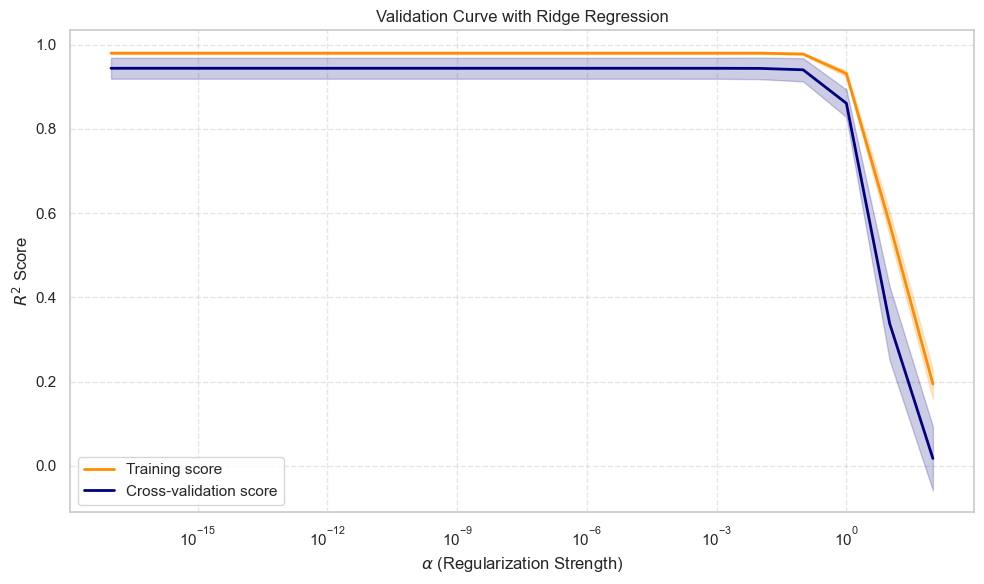

Optimal alpha based on extended validation curve: 1e-14


In [57]:
# --- Visualizing Overfitting: Ridge Validation Curve ---
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import validation_curve

# 1. Define an extended, broader range for alpha using a logarithmic scale
# This creates an array: [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000, 100000]
extended_param_range = np.logspace(-17, 2, 20)

# 2. Compute scores for the validation curve
print("Computing validation curve. This may take a moment...")
train_scores, test_scores = validation_curve(
    ridge_pipeline, 
    X_train, 
    Y_train, 
    param_name="regressor__alpha", 
    param_range=extended_param_range,
    cv=5, 
    scoring="r2", 
    n_jobs=-1
)

# 3. Calculate mean and standard deviation for train and test scores
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# 4. Plot the Validation Curve
plt.figure(figsize=(10, 6))
plt.title("Validation Curve with Ridge Regression")
plt.xlabel(r"$\alpha$ (Regularization Strength)")
plt.ylabel(r"$R^2$ Score")

# Plot training scores
plt.semilogx(extended_param_range, train_mean, label="Training score", color="darkorange", lw=2)
plt.fill_between(extended_param_range, train_mean - train_std, train_mean + train_std, alpha=0.2, color="darkorange")

# Plot cross-validation scores
plt.semilogx(extended_param_range, test_mean, label="Cross-validation score", color="navy", lw=2)
plt.fill_between(extended_param_range, test_mean - test_std, test_mean + test_std, alpha=0.2, color="navy")

plt.legend(loc="best")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

# 5. Output the best theoretical alpha from this expanded sweep
best_index = np.argmax(test_mean)
print(f"Optimal alpha based on extended validation curve: {extended_param_range[best_index]}")

Computing Lasso validation curve. This may take a moment...


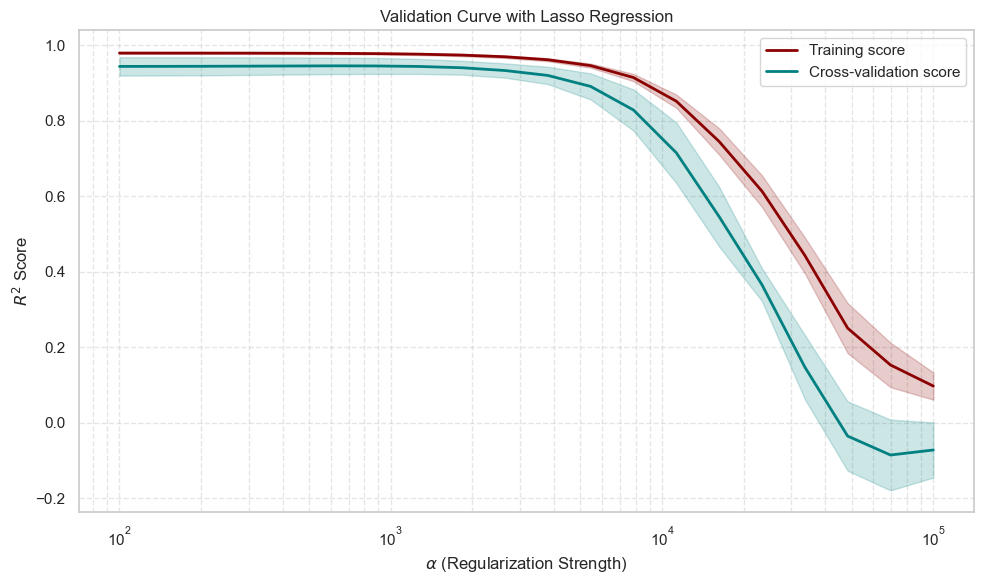

Optimal alpha based on Lasso validation curve: 615.8482110660267


In [58]:
# --- Visualizing Overfitting: Lasso Validation Curve ---

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import validation_curve

# 1. Define a specific parameter range for Lasso
# Lasso typically requires smaller alpha values than Ridge.
# This creates an array: [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
lasso_param_range = np.logspace(2, 5, 20)

# 2. Compute scores for the validation curve
print("Computing Lasso validation curve. This may take a moment...")
train_scores_lasso, test_scores_lasso = validation_curve(
    lasso_pipeline, 
    X_train, 
    Y_train, 
    param_name="regressor__alpha", 
    param_range=lasso_param_range,
    cv=5, 
    scoring="r2", 
    n_jobs=-1
)

# 3. Calculate mean and standard deviation for train and test scores
train_mean_lasso = np.mean(train_scores_lasso, axis=1)
train_std_lasso = np.std(train_scores_lasso, axis=1)
test_mean_lasso = np.mean(test_scores_lasso, axis=1)
test_std_lasso = np.std(test_scores_lasso, axis=1)

# 4. Plot the Validation Curve
plt.figure(figsize=(10, 6))
plt.title("Validation Curve with Lasso Regression")
plt.xlabel(r"$\alpha$ (Regularization Strength)")
plt.ylabel(r"$R^2$ Score")

# Plot training scores
plt.semilogx(lasso_param_range, train_mean_lasso, label="Training score", color="darkred", lw=2)
plt.fill_between(lasso_param_range, train_mean_lasso - train_std_lasso, train_mean_lasso + train_std_lasso, alpha=0.2, color="darkred")

# Plot cross-validation scores
plt.semilogx(lasso_param_range, test_mean_lasso, label="Cross-validation score", color="teal", lw=2)
plt.fill_between(lasso_param_range, test_mean_lasso - test_std_lasso, test_mean_lasso + test_std_lasso, alpha=0.2, color="teal")

plt.legend(loc="best")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

# 5. Output the best theoretical alpha from this sweep
best_index_lasso = np.argmax(test_mean_lasso)
print(f"Optimal alpha based on Lasso validation curve: {lasso_param_range[best_index_lasso]}")

## 3.4 Final Optimization: Extended Grid Search

In [59]:
# --- 3.4 Final Optimization: Extended Grid Search ---
import numpy as np

# 1. Define specific extended parameter grids based on validation curves
# 20 points are used to maintain high resolution without excessive computation time
param_grid_ridge_ext = {
    'regressor__alpha': np.logspace(-17, 2, 20) 
}

param_grid_lasso_ext = {
    'regressor__alpha': np.logspace(2, 5, 20) 
}

# --- EXTENDED RIDGE REGRESSION ---
print("Starting MLflow run for EXTENDED Ridge Regression...")
grid_search_ridge_ext = GridSearchCV(
    ridge_pipeline, 
    param_grid_ridge_ext, 
    cv=5, 
    scoring='r2',
    verbose=1,
    n_jobs=-1 
)

with mlflow.start_run(run_name="Ridge_GridSearch_Extended"):
    grid_search_ridge_ext.fit(X_train, Y_train)
    
    best_ridge_ext = grid_search_ridge_ext.best_estimator_
    best_alpha_ridge_ext = grid_search_ridge_ext.best_params_['regressor__alpha']
    
    r2_train_ridge_ext = r2_score(Y_train, best_ridge_ext.predict(X_train))
    r2_test_ridge_ext = r2_score(Y_test, best_ridge_ext.predict(X_test))
    
    mlflow.log_param("model_type", "Ridge_Extended")
    mlflow.log_param("best_alpha", best_alpha_ridge_ext)
    mlflow.log_metric("r2_train", r2_train_ridge_ext)
    mlflow.log_metric("r2_test", r2_test_ridge_ext)
    mlflow.sklearn.log_model(best_ridge_ext, "ridge_pipeline_extended")
    
    print(f"Extended Ridge Best Alpha: {best_alpha_ridge_ext}")
    print(f"Extended Ridge R2 Train: {r2_train_ridge_ext:.4f} | R2 Test: {r2_test_ridge_ext:.4f}\n")


# --- EXTENDED LASSO REGRESSION ---
print("Starting MLflow run for EXTENDED Lasso Regression...")
grid_search_lasso_ext = GridSearchCV(
    lasso_pipeline, 
    param_grid_lasso_ext, 
    cv=5, 
    scoring='r2',
    verbose=1,
    n_jobs=-1 
)

with mlflow.start_run(run_name="Lasso_GridSearch_Extended"):
    grid_search_lasso_ext.fit(X_train, Y_train)
    
    best_lasso_ext = grid_search_lasso_ext.best_estimator_
    best_alpha_lasso_ext = grid_search_lasso_ext.best_params_['regressor__alpha']
    
    r2_train_lasso_ext = r2_score(Y_train, best_lasso_ext.predict(X_train))
    r2_test_lasso_ext = r2_score(Y_test, best_lasso_ext.predict(X_test))
    
    mlflow.log_param("model_type", "Lasso_Extended")
    mlflow.log_param("best_alpha", best_alpha_lasso_ext)
    mlflow.log_metric("r2_train", r2_train_lasso_ext)
    mlflow.log_metric("r2_test", r2_test_lasso_ext)
    mlflow.sklearn.log_model(best_lasso_ext, "lasso_pipeline_extended")
    
    print(f"Extended Lasso Best Alpha: {best_alpha_lasso_ext}")
    print(f"Extended Lasso R2 Train: {r2_train_lasso_ext:.4f} | R2 Test: {r2_test_lasso_ext:.4f}")

Starting MLflow run for EXTENDED Ridge Regression...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


2026/02/28 19:36:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
c:\Users\ENava\anaconda3\envs\dsfs-base\Lib\site-packages\mlflow\models\model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format.
  flavor.save_model(path=local_path, mlflow_model=mlflow_model, **kwargs)


Extended Ridge Best Alpha: 1e-14
Extended Ridge R2 Train: 0.9777 | R2 Test: 0.8900

Starting MLflow run for EXTENDED Lasso Regression...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


2026/02/28 19:36:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
c:\Users\ENava\anaconda3\envs\dsfs-base\Lib\site-packages\mlflow\models\model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format.
  flavor.save_model(path=local_path, mlflow_model=mlflow_model, **kwargs)


Extended Lasso Best Alpha: 615.8482110660267
Extended Lasso R2 Train: 0.9770 | R2 Test: 0.8976
